In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LogNorm
from config import PROCESSED_DIR, FIGURES_DIR, REGION, CMIP6_VARS, TRAIN_END
import matplotlib

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "figure.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
})


In [2]:
def savefig(fig, name):
    p = FIGURES_DIR / name
    fig.savefig(p, dpi=200, bbox_inches="tight")
    print(f"Save: {p.name}")


def make_map_ax(fig, pos, title=""):
    ax = fig.add_subplot(pos, projection=ccrs.PlateCarree())
    ax.set_extent([REGION["lon_min"], REGION["lon_max"],
                    REGION["lat_min"], REGION["lat_max"]])
    ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=2)
    ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title)
    return ax


def fig_mean_chla(ds):
    mean_chla = ds["chlor_a"].mean(dim="time")

    fig = plt.figure(figsize=(9, 6))
    ax = make_map_ax(fig, 111, "Mean chl-a")
    pcm = ax.pcolormesh(ds["lon"], ds["lat"], mean_chla,
                        norm=LogNorm(vmin=0.01, vmax=10),
                        cmap="YlGnBu", transform=ccrs.PlateCarree())
    fig.colorbar(pcm, ax=ax, shrink=0.75, label="chl-a (mg/m$^3$)")
    plt.show()
    savefig(fig, "fig_mean_chla.png")


def fig_seasonal(ds):
    seasons = {"DJF": [12, 1, 2], "MAM": [3, 4, 5],
               "JJA": [6, 7, 8], "SON": [9, 10, 11]}

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("Seasonal chl-a", fontsize=14, y=0.98)

    gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.05],
                  wspace=0.25, hspace=0.25)

    map_axes = []
    for idx, (name, months) in enumerate(seasons.items()):
        row, col = divmod(idx, 2)
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        ax.set_extent([REGION["lon_min"], REGION["lon_max"],
                        REGION["lat_min"], REGION["lat_max"]])
        ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=2)
        ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
        gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.5)
        gl.top_labels = gl.right_labels = False
        ax.set_title(name)
        map_axes.append(ax)

        seasonal = ds["chlor_a"].where(
            ds["time.month"].isin(months), drop=True).mean(dim="time")
        pcm = ax.pcolormesh(ds["lon"], ds["lat"], seasonal,
                            norm=LogNorm(vmin=0.01, vmax=10),
                            cmap="YlGnBu", transform=ccrs.PlateCarree())

    cbar_ax = fig.add_subplot(gs[:, 2])
    fig.colorbar(pcm, cax=cbar_ax, label="chl-a (mg/m$^3$)")
    plt.show()
    savefig(fig, "fig_seasonal_chla.png")


def fig_timeseries(ds):
    ts = ds["chlor_a"].mean(dim=["lat", "lon"], skipna=True)
    ts_log = ds["log_chla"].mean(dim=["lat", "lon"], skipna=True)
    times = pd.to_datetime(ts.time.values)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax1.plot(times, ts.values, "o-", ms=2, lw=0.8, color="#2c7bb6")
    ax1.axvline(pd.Timestamp(TRAIN_END), color="red", ls="--", lw=1.2, label="Train/Test split")
    ax1.set_ylabel("chl-a (mg/m$^3$)")
    ax1.set_title("Area-Mean chl-a Time Series")
    ax1.legend()

    ax2.plot(times, ts_log.values, "o-", ms=2, lw=0.8, color="#d7191c")
    ax2.axvline(pd.Timestamp(TRAIN_END), color="red", ls="--", lw=1.2)
    ax2.set_ylabel("log10(chl-a)")
    ax2.set_xlabel("Time")

    fig.tight_layout()
    plt.show()
    savefig(fig, "fig_timeseries.png")


def fig_correlation(df):
    cols = ["log_chla"] + CMIP6_VARS
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols, fontsize=9)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(corr.values[i, j]) > 0.5 else "black")
    fig.colorbar(im, shrink=0.8, label="Pearson r")
    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()
    savefig(fig, "fig_correlation.png")


def fig_cmip6_spatial(ds):
    var_info = {
        "mlotst": {"label": "MLD", "unit": "m", "cmap": "RdYlBu_r"},
        "tos": {"label": "SST", "unit": "°C", "cmap": "RdYlBu_r"},
        "no3": {"label": "NO₃", "unit": "mol/m³", "cmap": "YlOrRd"},
        "po4": {"label": "PO₄", "unit": "mol/m³", "cmap": "YlOrRd"},
        "si": {"label": "Si", "unit": "mol/m³", "cmap": "YlOrRd"},
        "dfe": {"label": "dFe", "unit": "mol/m³", "cmap": "YlOrRd"},
        "o2": {"label": "O₂", "unit": "mol/m³", "cmap": "YlGnBu"},
    }

    n = len(var_info)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows),
                             subplot_kw={"projection": ccrs.PlateCarree()},
                             gridspec_kw={"hspace": 0.15, "wspace": 0.35})

    axes_flat = axes.flatten()

    for idx, (var, info) in enumerate(var_info.items()):
        ax = axes_flat[idx]
        ax.set_extent([REGION["lon_min"], REGION["lon_max"],
                        REGION["lat_min"], REGION["lat_max"]])
        ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=2)
        ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
        gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.5)
        gl.top_labels = gl.right_labels = False
        ax.set_title(f"{info['label']}", fontsize=11)

        mean_val = ds[var].mean(dim="time")
        pcm = ax.pcolormesh(ds["lon"], ds["lat"], mean_val,
                            cmap=info["cmap"], transform=ccrs.PlateCarree())

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1,
                                  axes_class=plt.Axes)
        cbar = fig.colorbar(pcm, cax=cax, label=info["unit"])
        cbar.formatter = ScalarFormatter(useMathText=False)
        cbar.formatter.set_powerlimits((-2, 2))
        cbar.update_ticks()

    for idx in range(n, nrows * ncols):
        axes_flat[idx].set_visible(False)

    fig.subplots_adjust(hspace=0.15, wspace=0.35)
    plt.show()
    savefig(fig, "fig_cmip6_spatial.png")

In [3]:
nc_path = PROCESSED_DIR / "SCS_CMIP6_MODIS_1deg.nc"
pq_path = PROCESSED_DIR / "SCS_CMIP6_MODIS_flat.parquet"
ds = xr.open_dataset(nc_path)
df = pd.read_parquet(pq_path)

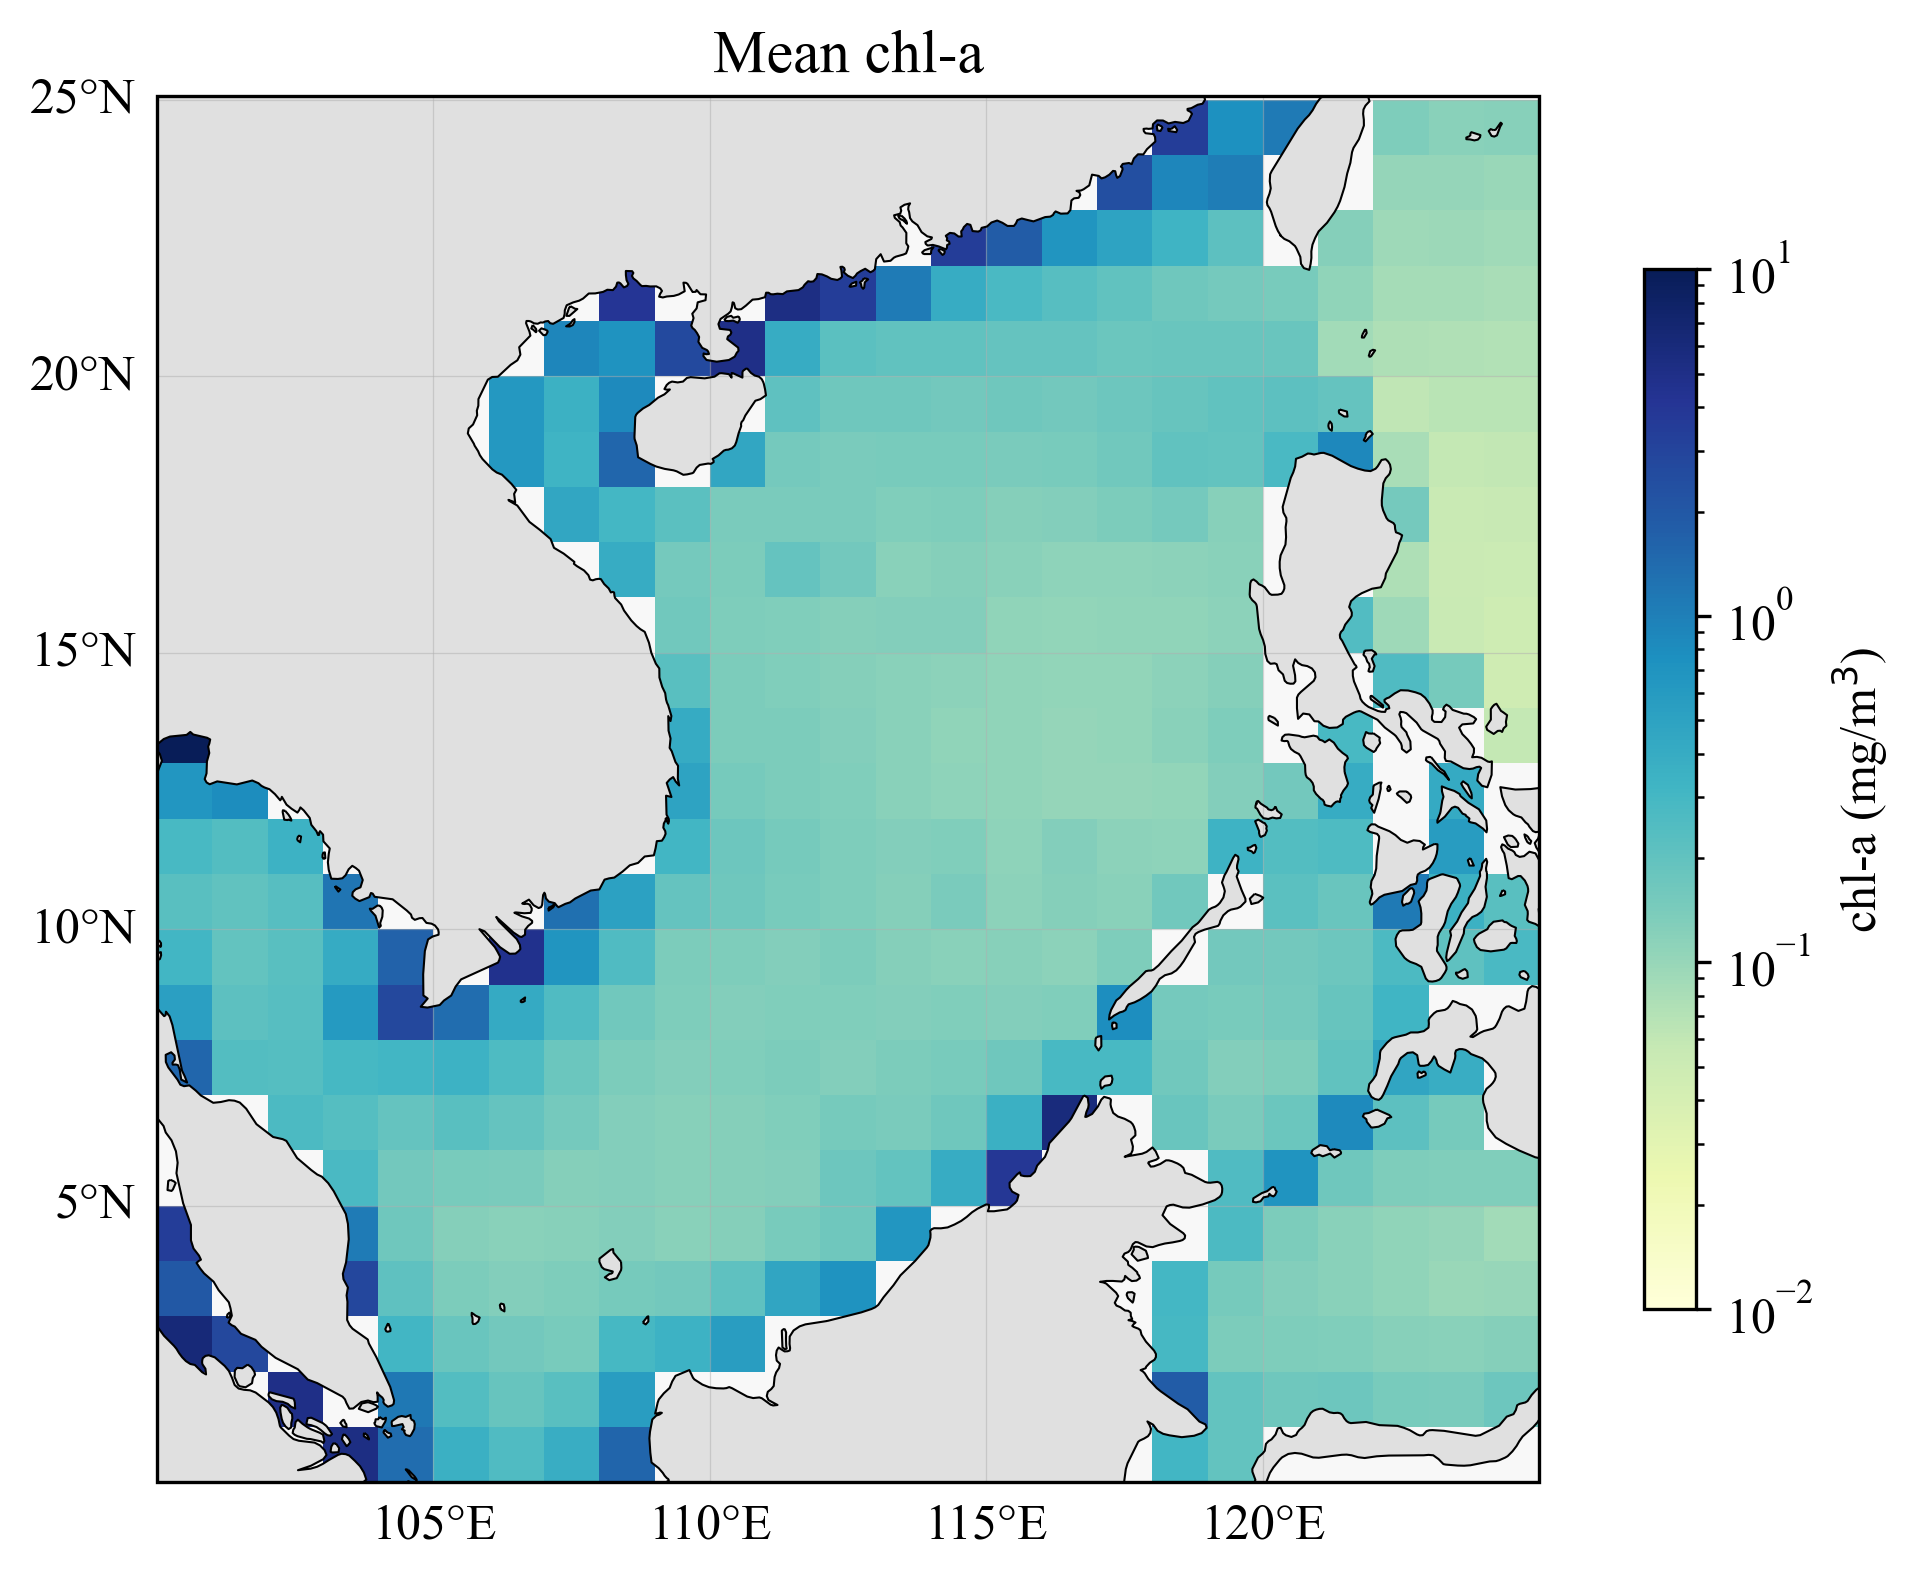

Save: fig_mean_chla.png


In [4]:
fig_mean_chla(ds)

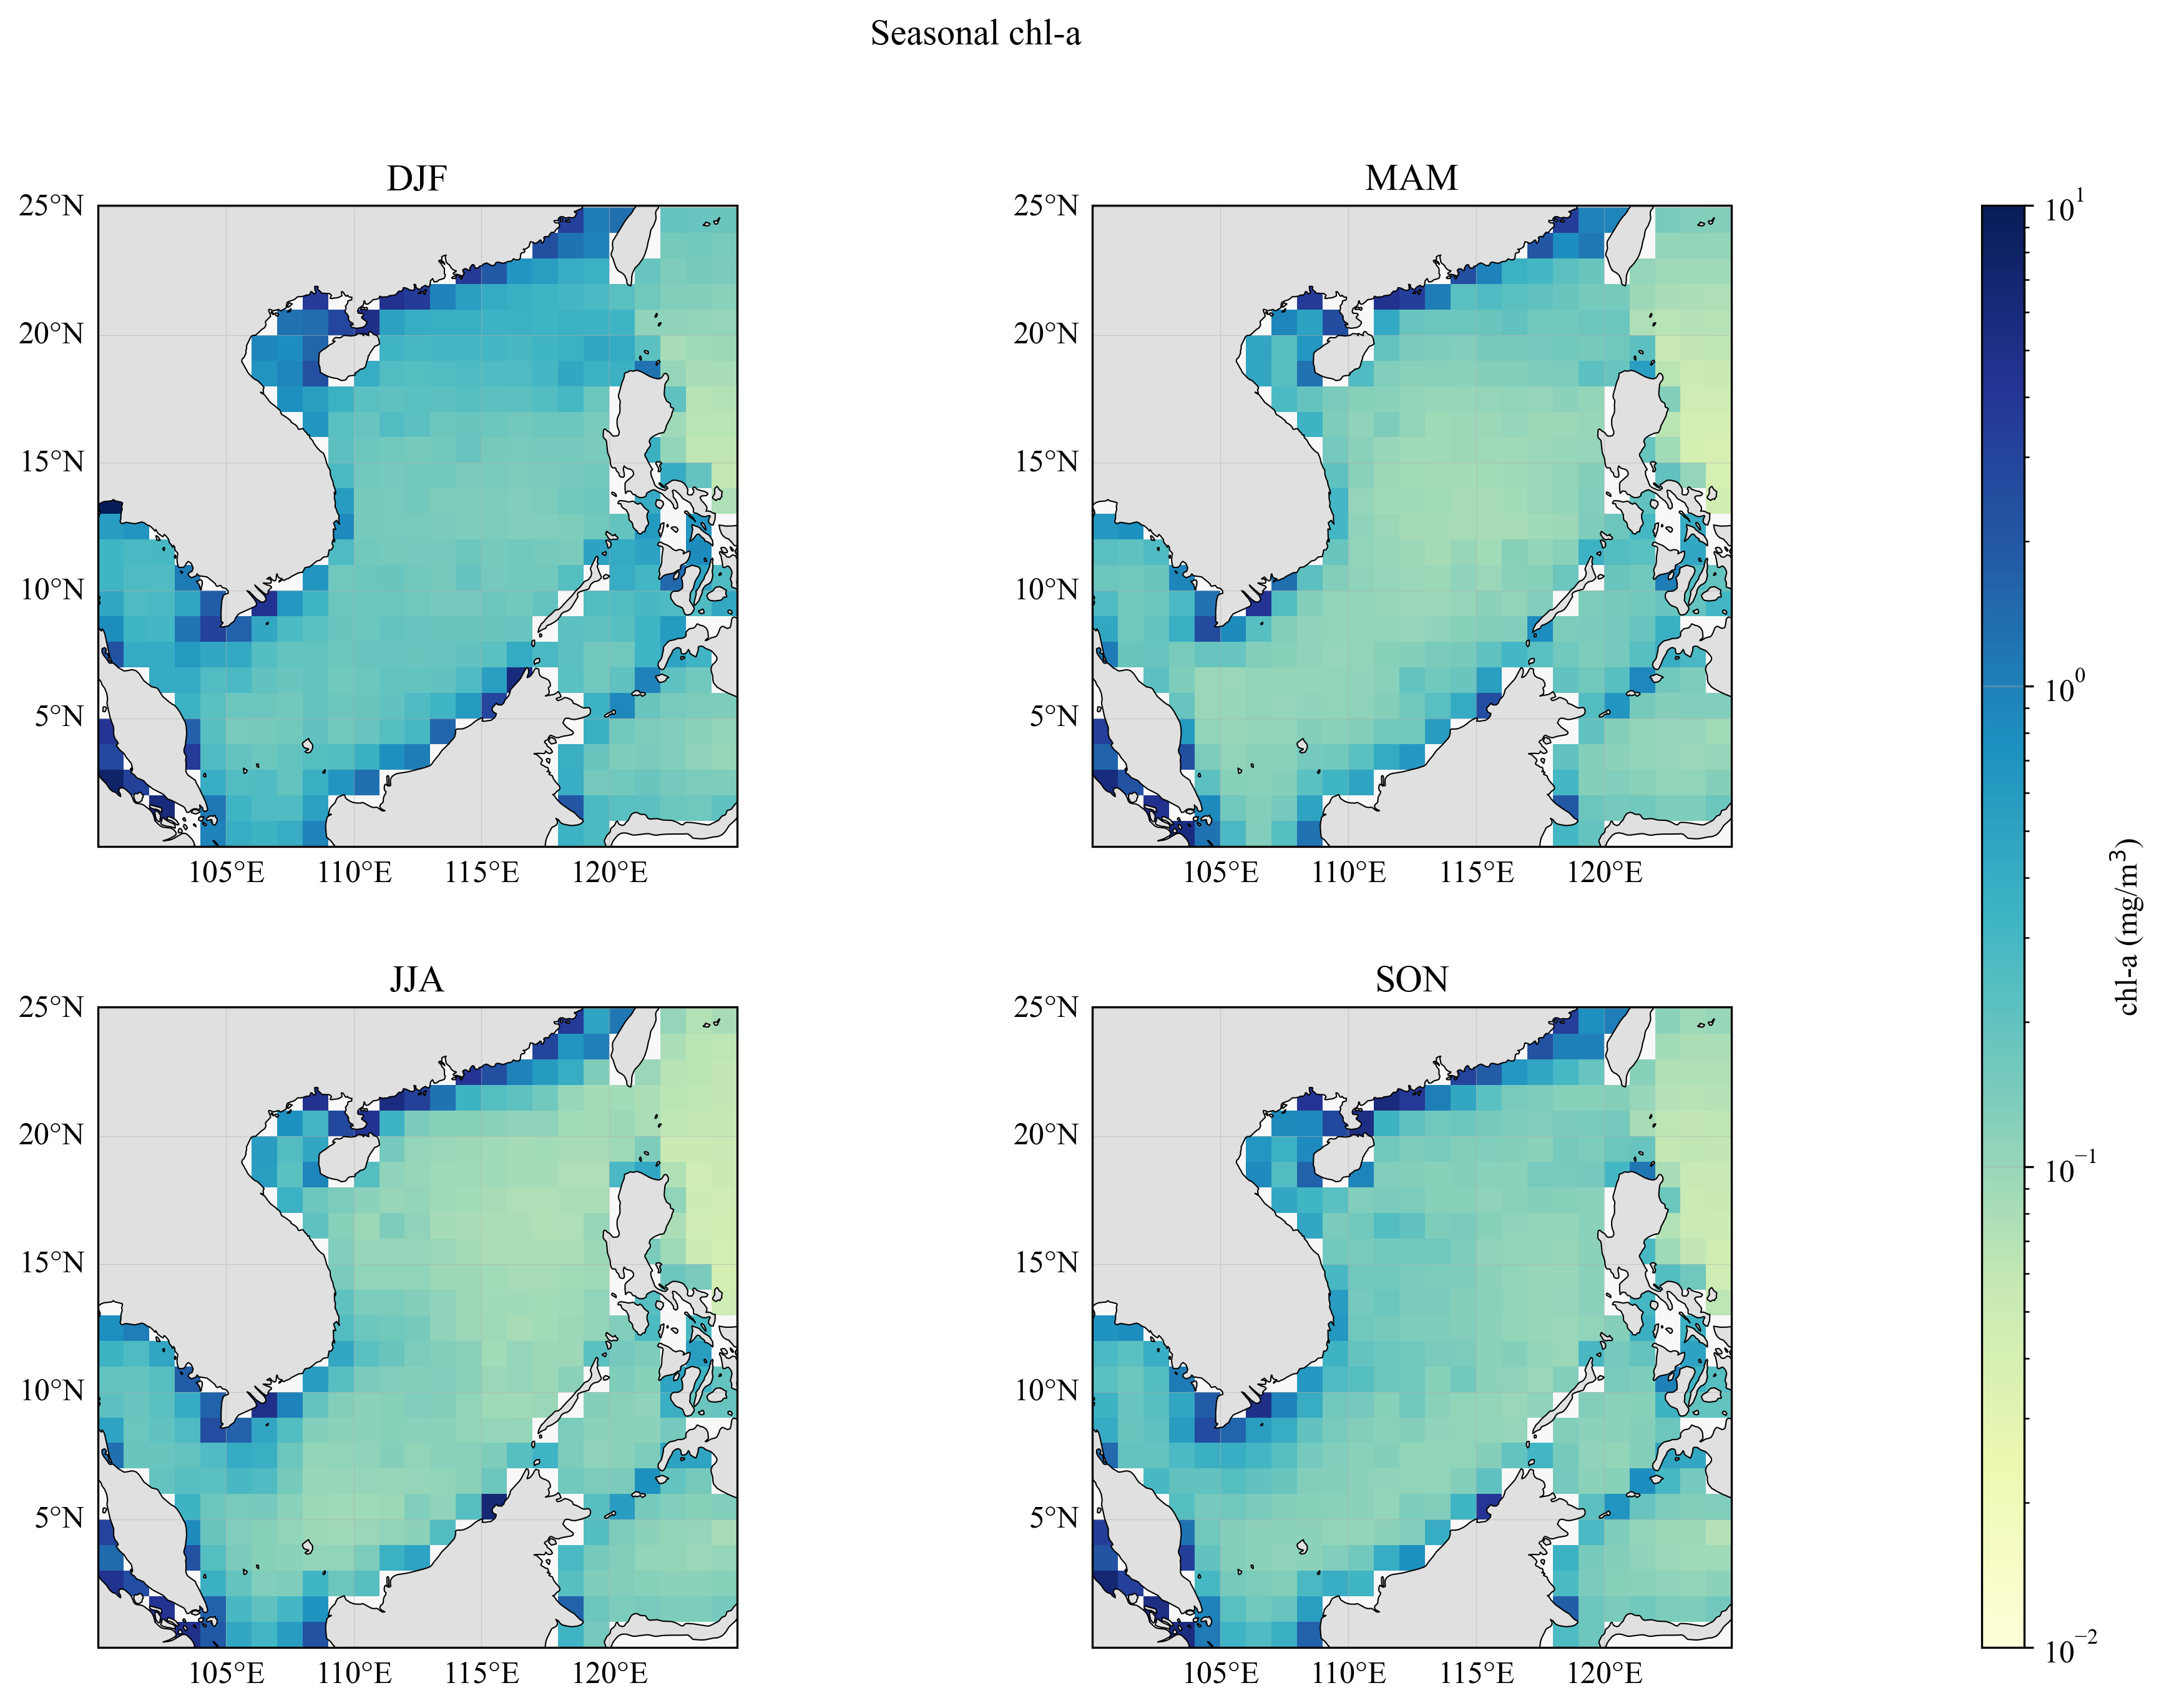

Save: fig_seasonal_chla.png


In [5]:
fig_seasonal(ds)

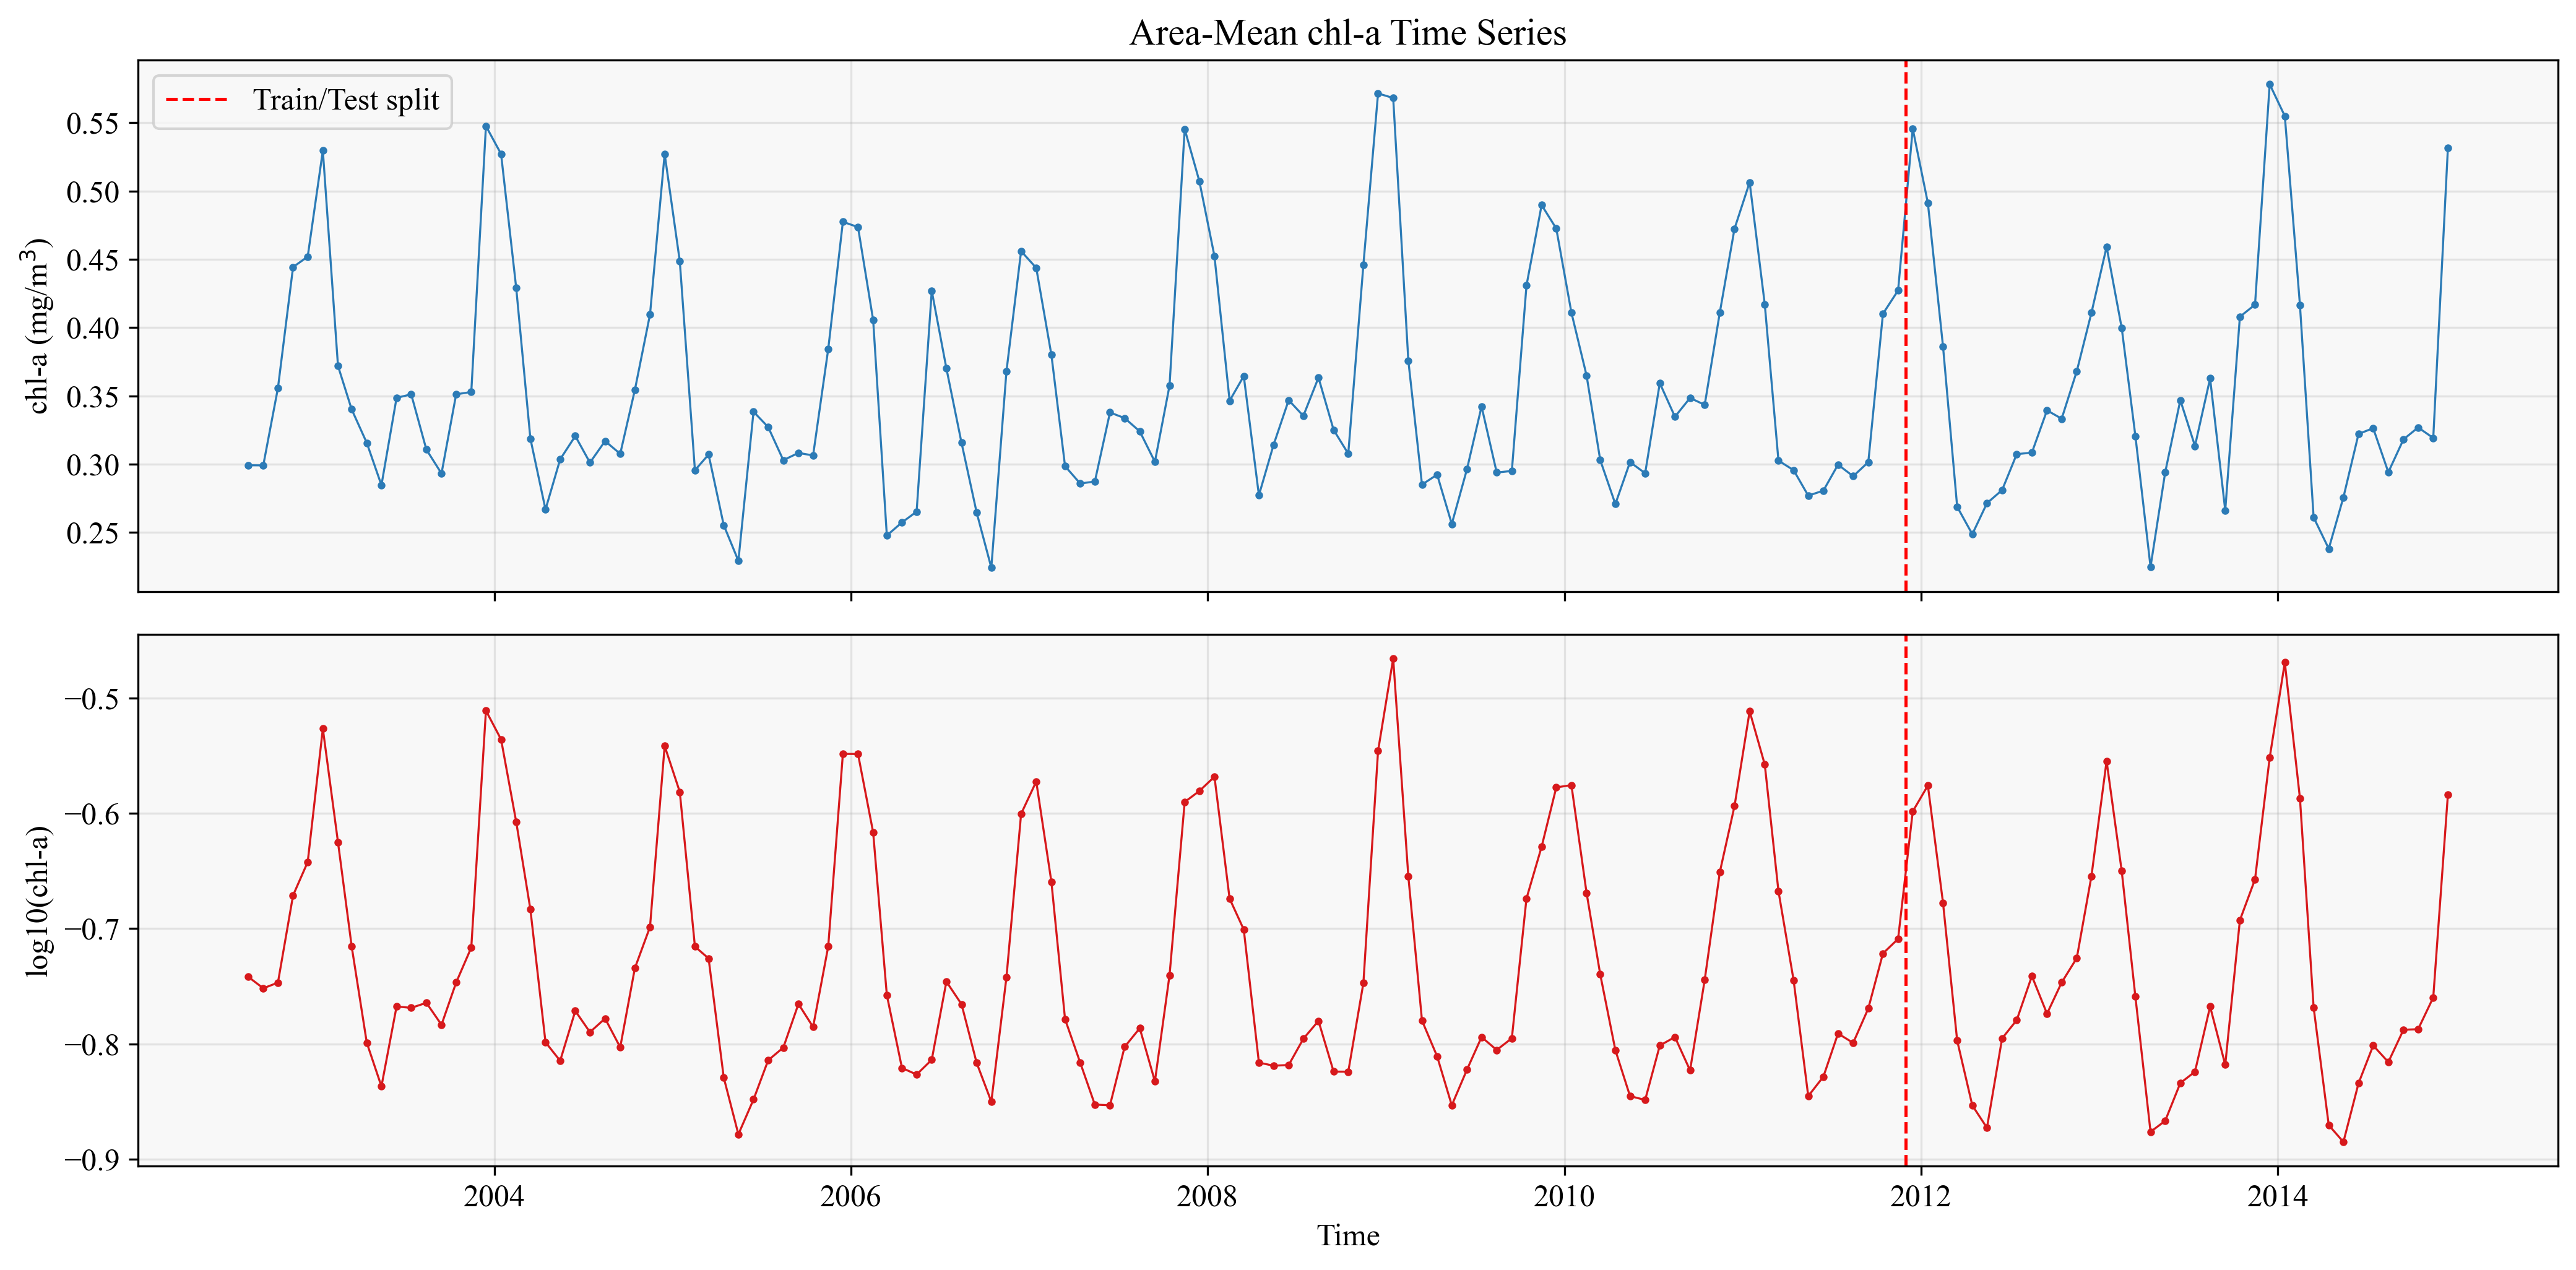

Save: fig_timeseries.png


In [6]:
fig_timeseries(ds)

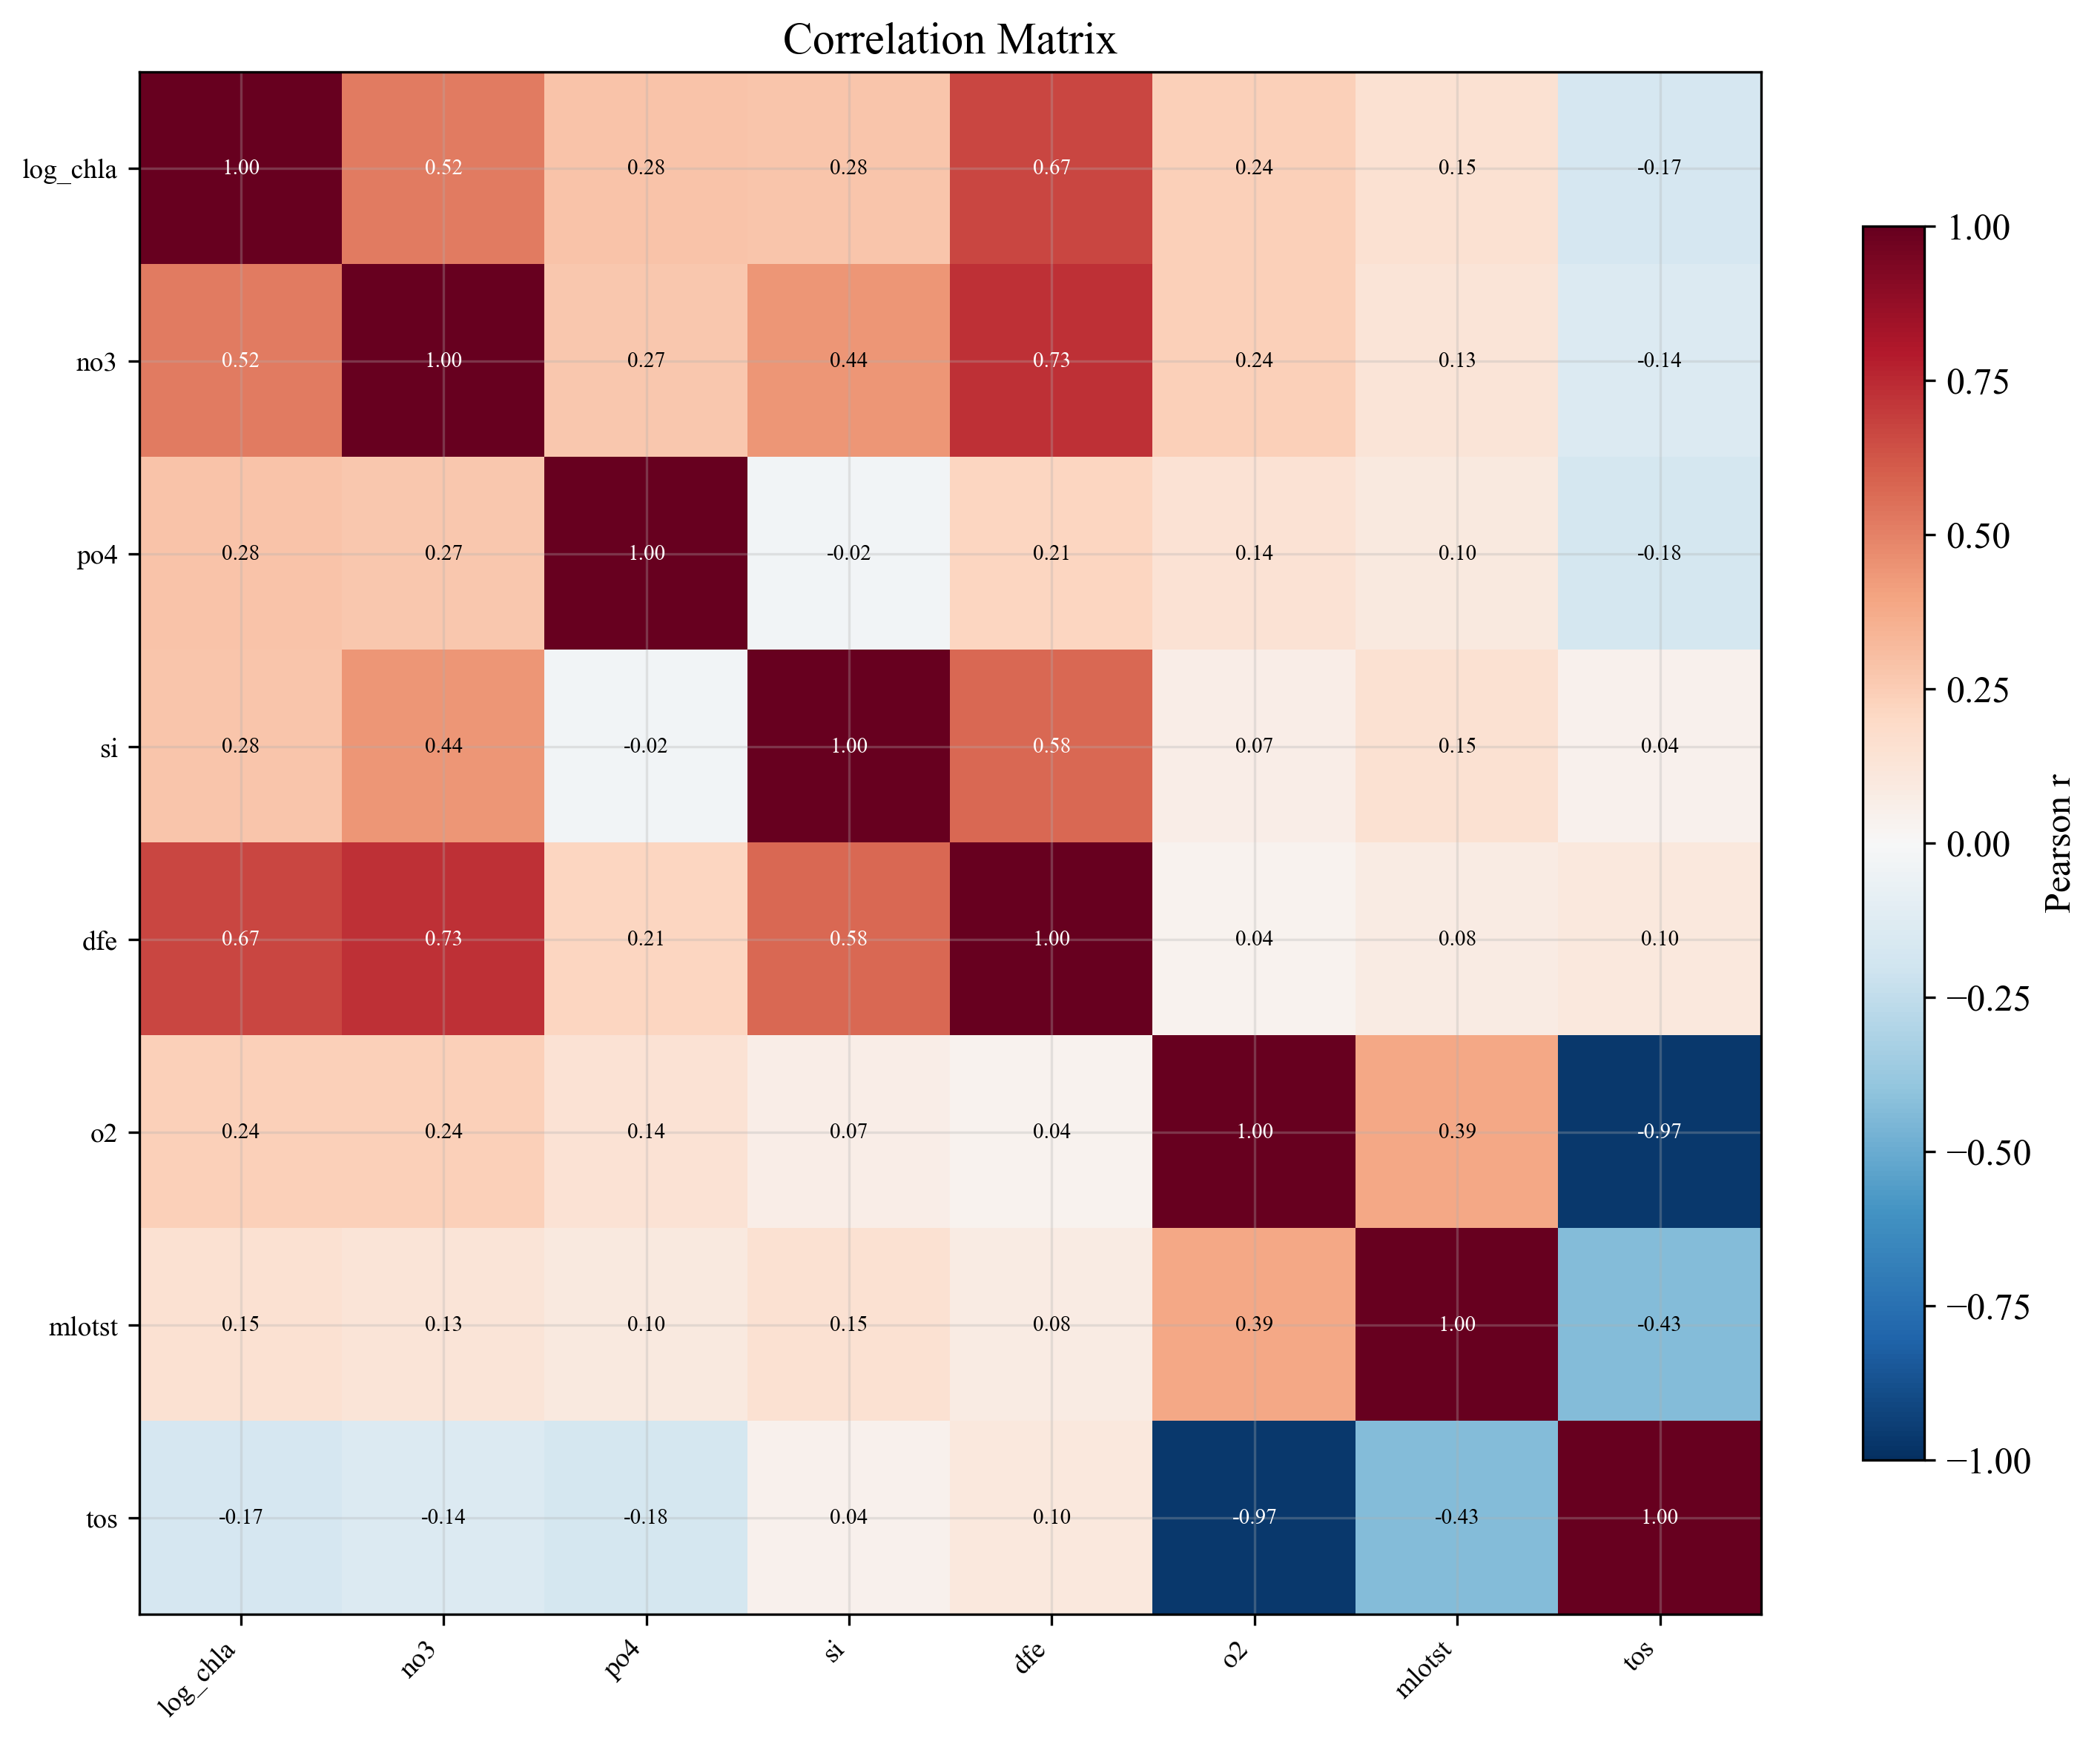

Save: fig_correlation.png


In [7]:
fig_correlation(df)

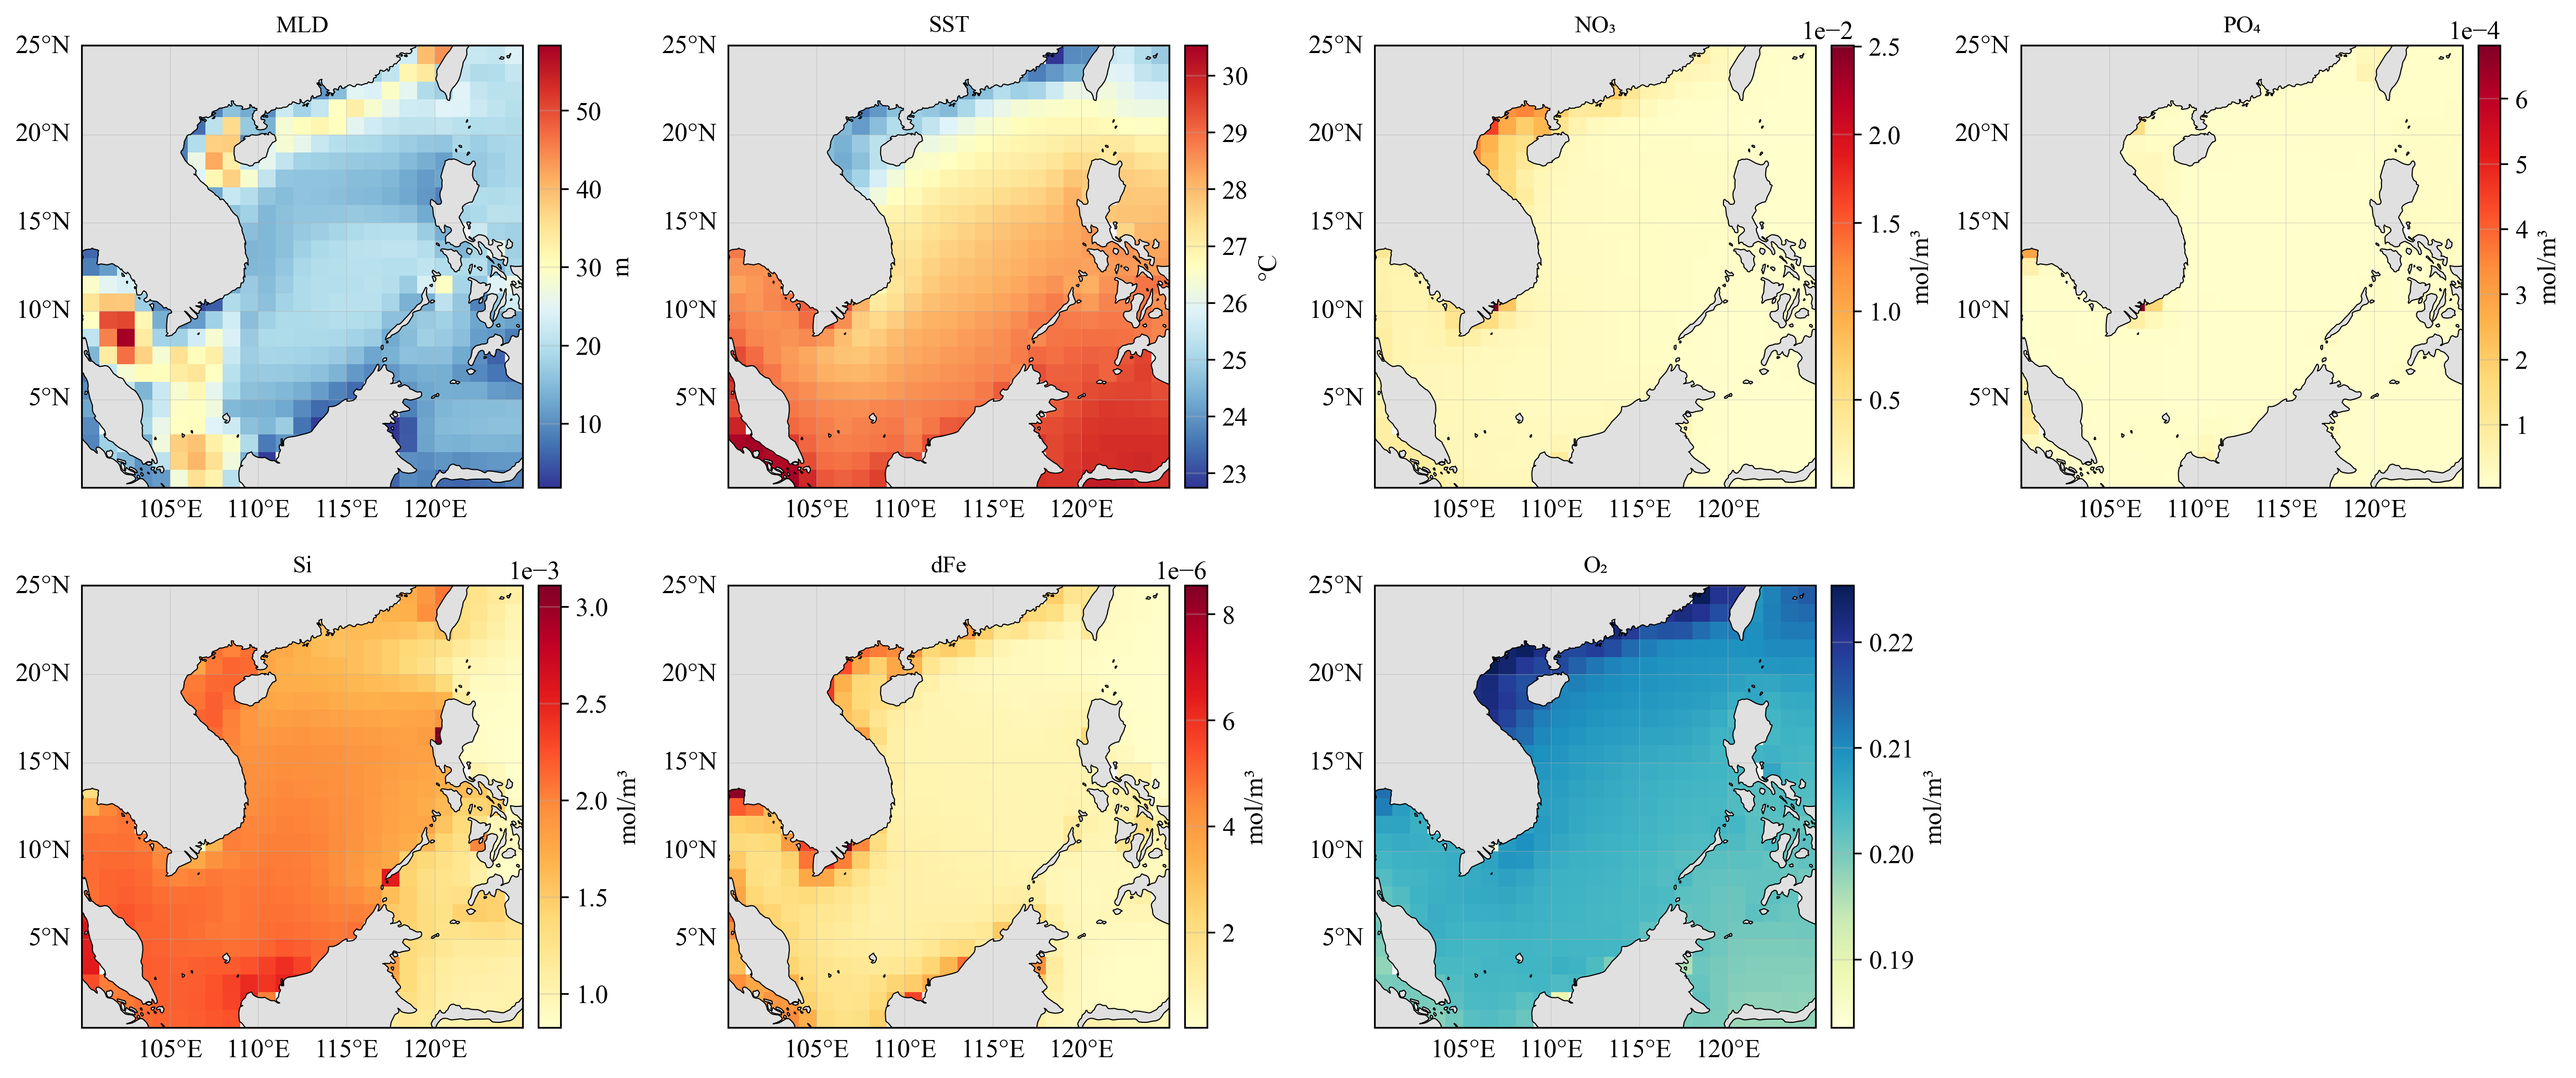

Save: fig_cmip6_spatial.png


In [8]:
fig_cmip6_spatial(ds)